# TT-18 — 01. Kham pha & lam sach du lieu
Ames Housing — thiet lap missing-value handling, ma hoa thu tu, va kiem tra do lech nhan.

**Yeu cau du lieu:** dat file `train.csv` cua bo Kaggle *House Prices - Advanced Regression Techniques* vao thu muc `../data/` truoc khi chay notebook nay (xem README.md).

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
import features as feat

pd.set_option('display.max_columns', 50)
DATA_PATH = '../data/train.csv'

## 1. Doc du lieu

In [2]:
df_raw = feat.load_data(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Thong ke & phan loai gia tri thieu
Phan biet **'khong co tien ich'** (NaN co y nghia — vd `PoolQC=NaN` nghia la nha khong co be boi) voi **'thieu that'** (can dien median/mode).

In [3]:
report = feat.missing_value_report(df_raw)
report

,cot,so_dong_thieu,ty_le_%,phan_loai
0,PoolQC,1453,99.5,khong_co_tien_ich (NaN co y nghia)
1,MiscFeature,1406,96.3,khong_co_tien_ich (NaN co y nghia)
2,Alley,1369,93.8,khong_co_tien_ich (NaN co y nghia)
3,Fence,1179,80.8,khong_co_tien_ich (NaN co y nghia)
4,MasVnrType,872,59.7,khong_co_tien_ich (NaN co y nghia)
5,FireplaceQu,690,47.3,khong_co_tien_ich (NaN co y nghia)
6,LotFrontage,259,17.7,thieu_that (se dien median)
7,GarageType,81,5.5,khong_co_tien_ich (NaN co y nghia)
8,GarageYrBlt,81,5.5,khong_co_tien_ich (NaN co y nghia)
9,GarageFinish,81,5.5,khong_co_tien_ich (NaN co y nghia)


So cot 'khong co tien ich' (NaN co y nghia): 17
So cot 'thieu that' (se dien median/mode):   2


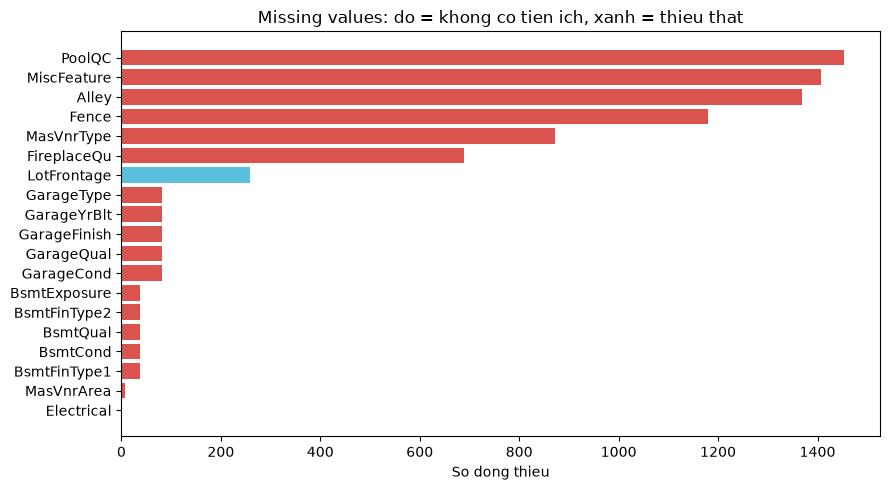

In [4]:
n_none = report['phan_loai'].str.contains('khong_co_tien_ich').sum()
n_true = len(report) - n_none
print(f"So cot 'khong co tien ich' (NaN co y nghia): {n_none}")
print(f"So cot 'thieu that' (se dien median/mode):   {n_true}")

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d9534f' if 'khong_co_tien_ich' in c else '#5bc0de' for c in report['phan_loai']]
ax.barh(report['cot'], report['so_dong_thieu'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('So dong thieu')
ax.set_title("Missing values: do = khong co tien ich, xanh = thieu that")
fig.tight_layout()
fig.savefig('../reports/missing_analysis.png', dpi=130)
plt.show()

## 3. Xu ly gia tri thieu (khong xoa cot, khong xoa dong)

In [5]:
df_clean = feat.handle_missing(df_raw)
assert df_clean.isna().sum().sum() == 0, 'Van con gia tri thieu!'
print('Da xu ly xong. Con lai NaN:', df_clean.isna().sum().sum())
print('So cot khong doi (khong cot nao bi xoa):', df_clean.shape[1] == df_raw.shape[1])

Da xu ly xong. Con lai NaN: 0
So cot khong doi (khong cot nao bi xoa): True


## 4. Bien thu tu (Ordinal) va bien danh muc (Nominal)
Cac cot chat luong (`ExterQual`, `KitchenQual`, `BsmtQual`, ...) co thu tu ro rang `Po < Fa < TA < Gd < Ex`, nen duoc ma hoa bang `OrdinalEncoder` dung thu tu — khong dung one-hot vi se lam mat thong tin thu bac.

In [6]:
df_fe = feat.engineer_features(df_clean)
preprocessor, (num_cols, ord_cols, nom_cols) = feat.build_preprocessor(df_fe)
print(f'{len(ord_cols)} cot ordinal:', ord_cols)
print(f'{len(nom_cols)} cot nominal (one-hot):', nom_cols[:10], '...')
print(f'{len(num_cols)} cot numeric')

12 cot ordinal: ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC', 'BsmtExposure', 'GarageFinish']
31 cot nominal (one-hot): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...
39 cot numeric


## 5. Do lech nhan SalePrice → log1p
Vai can nha sieu dat lam nhan lech phai manh. Dung `log1p(SalePrice)` de huan luyen, va `expm1()` de doi nguoc khi bao cao gia du doan.

Skew(SalePrice)        = 1.881
Skew(log1p(SalePrice)) = 0.121


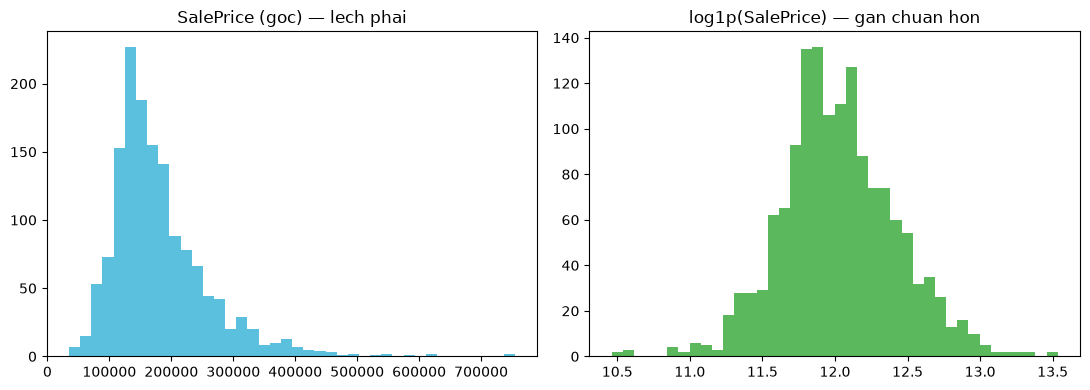

In [7]:
sale_price = df_fe['SalePrice']
log_price = np.log1p(sale_price)
print(f"Skew(SalePrice)        = {skew(sale_price):.3f}")
print(f"Skew(log1p(SalePrice)) = {skew(log_price):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sale_price, bins=40, color='#5bc0de')
axes[0].set_title('SalePrice (goc) — lech phai')
axes[1].hist(log_price, bins=40, color='#5cb85c')
axes[1].set_title('log1p(SalePrice) — gan chuan hon')
fig.tight_layout()
plt.show()

## 6. Feature engineering
`TotalSF = 1stFlrSF + 2ndFlrSF + TotalBsmtSF`, `TuoiNha = YrSold - YearBuilt`, `DaSuaChua = (YearRemodAdd != YearBuilt)` — hieu qua cua cac dac trung nay duoc danh gia (RMSE truoc/sau) trong notebook `02_gbr_model.ipynb`.

In [8]:
df_fe[['TotalSF', 'TuoiNha', 'DaSuaChua']].describe()

,TotalSF,TuoiNha,DaSuaChua
count,1460.000000,1460.000000,1460.000000
mean,2567.048630,36.547945,0.476712
std,821.714421,30.250152,0.499629
min,334.000000,0.000000,0.000000
25%,2009.500000,8.000000,0.000000
50%,2474.000000,35.000000,0.000000
75%,3004.000000,54.000000,1.000000
max,11752.000000,136.000000,1.000000


Du lieu da lam sach (`df_fe`) va bo tien xu ly (`preprocessor`) san sang cho buoc huan luyen mo hinh trong `02_gbr_model.ipynb`.